# Lab 3: Ridge, LASSO and the Elastic Net

**ECON5129 Statistical Machine Learning** &middot; Adam Smith Business School, University of Glasgow

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/korobilis/ECON5129-labs/blob/main/solutions/lab03_shrinkage_solutions.ipynb)

This lab accompanies Lecture 3. By the end of the session you should be able to:

1. Demonstrate the failure of least squares as the number of predictors approaches the sample size.
2. Decompose prediction error into bias, variance and noise by simulation, and locate the trade-off.
3. Implement ridge regression in closed form and read its behaviour off the singular value decomposition.
4. Implement the LASSO by coordinate descent, including the soft-thresholding operator.
5. Fit the elastic net and explain what it does that neither of its parents does.
6. Choose the penalty by cross-validation, respecting the time series structure of the data.
7. Forecast a macroeconomic series from 363 predictors and evaluate it honestly against an autoregressive benchmark.

From this lab onward, time series problems are indexed $t = 1, \dots, T$.

**Plan for the session**

| Time | Part |
|---|---|
| 0:00 - 0:20 | Part 1. Where least squares breaks |
| 0:20 - 0:40 | Part 2. Bias, variance and the trade-off |
| 0:40 - 1:05 | Part 3. Ridge regression |
| 1:05 - 1:30 | Part 4. The LASSO |
| 1:30 - 1:40 | Part 5. The elastic net |
| 1:40 - 2:00 | Part 6. Choosing the penalty, and a macro forecasting horse race |

## Setup

In [1]:
import os
import urllib.request

REPO_RAW = "https://raw.githubusercontent.com/korobilis/ECON5129-labs/main"

if not os.path.exists("econ5129_utils.py"):
    urllib.request.urlretrieve(f"{REPO_RAW}/econ5129_utils.py", "econ5129_utils.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import econ5129_utils as e5

e5.set_style()
rng = np.random.default_rng(5129)

## Part 1. Where least squares breaks

Least squares is unbiased and, among linear unbiased estimators, has the smallest variance. Neither property protects it when $p$ approaches $n$. We hold the sample size fixed and add predictors, all of which are genuinely irrelevant beyond the first ten.

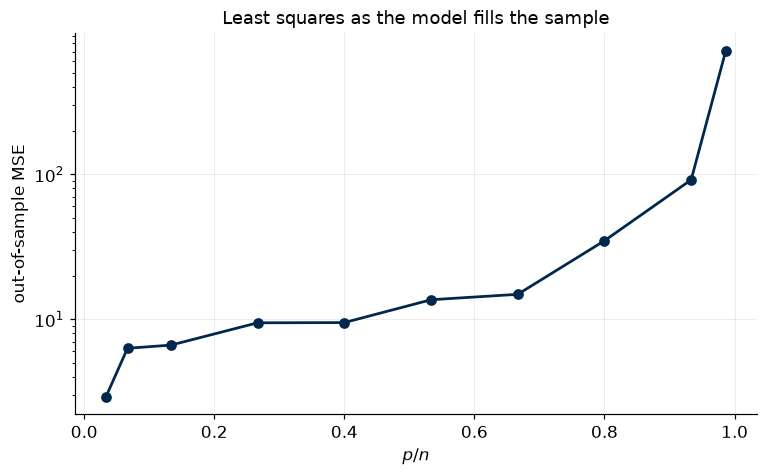

In [2]:
n_obs = 150
p_grid = [5, 10, 20, 40, 60, 80, 100, 120, 140, 148]
n_rep = 60

results = []
for p in p_grid:
    errors = []
    for _ in range(n_rep):
        X, y, beta = e5.simulate_sparse_regression(
            n=2 * n_obs, p=p, n_active=min(10, p), rho=0.3, seed=int(rng.integers(1e6))
        )
        X_tr, X_te = X[:n_obs], X[n_obs:]
        y_tr, y_te = y[:n_obs], y[n_obs:]
        b, *_ = np.linalg.lstsq(X_tr, y_tr, rcond=None)
        errors.append(e5.mse(y_te, X_te @ b))
    results.append(np.mean(errors))

fig, ax = plt.subplots()
ax.plot(np.array(p_grid) / n_obs, results, marker="o")
ax.set_yscale("log")
ax.set_xlabel("$p / n$")
ax.set_ylabel("out-of-sample MSE")
ax.set_title("Least squares as the model fills the sample")
plt.show()

The deterioration is not gentle. As $p/n \to 1$ the design matrix becomes nearly singular, the estimated coefficients explode, and predictions with them. Beyond $p = n$ there is no unique solution at all.

Regularisation gives up unbiasedness in exchange for variance, and the exchange is usually profitable.

## Part 2. Bias, variance and the trade-off

For a fixed prediction point $\mathbf{x}_0$ the expected squared error decomposes as

$$ \mathbb{E}\left[(y_0 - \widehat{f}(\mathbf{x}_0))^2\right] = \underbrace{\left(\mathbb{E}[\widehat{f}(\mathbf{x}_0)] - f(\mathbf{x}_0)\right)^2}_{\text{bias}^2} + \underbrace{\operatorname{Var}(\widehat{f}(\mathbf{x}_0))}_{\text{variance}} + \sigma^2 . $$

Every term is computable by simulation when we control the data generating process. We hold the design and the truth fixed, redraw the noise, and estimate ridge coefficients across a grid of penalties.

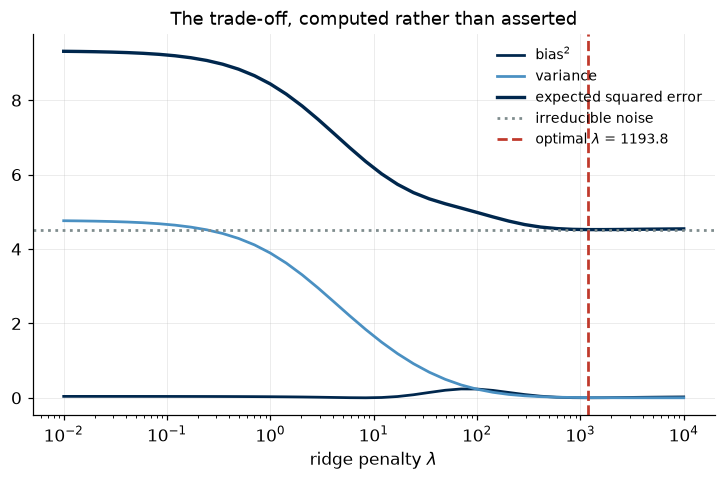

In [3]:
n_mc, n_fixed, p_fixed = 400, 100, 60

X_fixed, _, beta_fixed = e5.simulate_sparse_regression(
    n=n_fixed, p=p_fixed, n_active=10, rho=0.4, seed=7
)
x0 = e5.simulate_sparse_regression(n=1, p=p_fixed, n_active=10, rho=0.4, seed=11)[0][0]
f0 = x0 @ beta_fixed
sigma_noise = np.std(X_fixed @ beta_fixed) / np.sqrt(3.0)


def ridge_fit(X, y, lam):
    """Closed-form ridge estimator; the penalty is not applied to a constant."""
    p = X.shape[1]
    return np.linalg.solve(X.T @ X + lam * np.eye(p), X.T @ y)


lam_grid = np.logspace(-2, 4, 40)
preds = np.empty((len(lam_grid), n_mc))

for r in range(n_mc):
    y_r = X_fixed @ beta_fixed + sigma_noise * rng.normal(size=n_fixed)
    for j, lam in enumerate(lam_grid):
        preds[j, r] = x0 @ ridge_fit(X_fixed, y_r, lam)

bias2 = (preds.mean(axis=1) - f0) ** 2
variance = preds.var(axis=1)
total = bias2 + variance + sigma_noise ** 2

fig, ax = plt.subplots()
ax.plot(lam_grid, bias2, label="bias$^2$")
ax.plot(lam_grid, variance, label="variance")
ax.plot(lam_grid, total, color=e5.COLORS[0], lw=2.2, label="expected squared error")
ax.axhline(sigma_noise ** 2, color=e5.COLORS[6], ls=":", label="irreducible noise")
ax.axvline(lam_grid[int(np.argmin(total))], color=e5.COLORS[2], ls="--",
           label=f"optimal $\\lambda$ = {lam_grid[int(np.argmin(total))]:.1f}")
ax.set_xscale("log")
ax.set_xlabel(r"ridge penalty $\lambda$")
ax.set_title("The trade-off, computed rather than asserted")
ax.legend(fontsize=9)
plt.show()

The minimum sits at a strictly positive penalty. That single fact is the entire argument for shrinkage: the unbiased estimator, at $\lambda = 0$, is never the best predictor here.

### Exercise 1

The location of the optimum depends on how much signal there is relative to noise.

1. Repeat the experiment with a signal-to-noise ratio of 10 rather than 3, by rescaling `sigma_noise`.
2. Repeat it again with a ratio of 1.
3. Plot the three total-error curves together, and report how the optimal penalty moves.

State the general principle in one sentence.

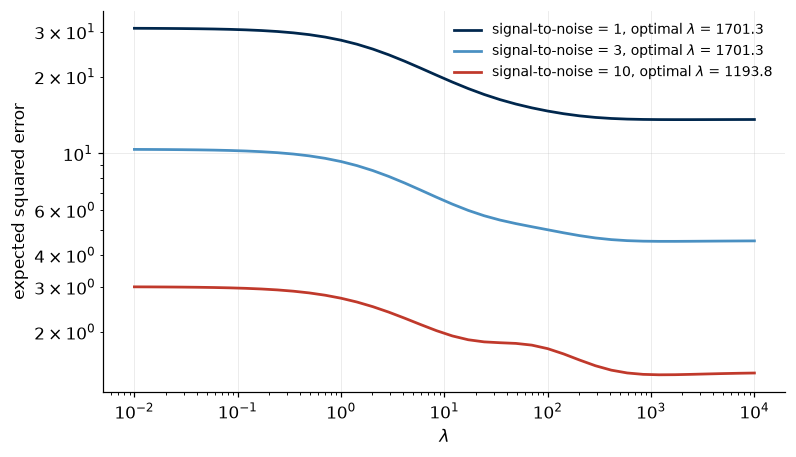

In [4]:
def bias_variance_curve(snr):
    """Expected squared error at x0 across the ridge penalty grid."""
    sigma_s = np.std(X_fixed @ beta_fixed) / np.sqrt(snr)
    p_hat = np.empty((len(lam_grid), n_mc))
    for r in range(n_mc):
        y_r = X_fixed @ beta_fixed + sigma_s * rng.normal(size=n_fixed)
        for j, lam in enumerate(lam_grid):
            p_hat[j, r] = x0 @ ridge_fit(X_fixed, y_r, lam)
    return (p_hat.mean(axis=1) - f0) ** 2 + p_hat.var(axis=1) + sigma_s ** 2


fig, ax = plt.subplots()
for snr in [1.0, 3.0, 10.0]:
    curve = bias_variance_curve(snr)
    ax.plot(lam_grid, curve, label=f"signal-to-noise = {snr:g}, "
                                   f"optimal $\\lambda$ = {lam_grid[int(np.argmin(curve))]:.1f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("expected squared error")
ax.legend(fontsize=9)
plt.show()

## Part 3. Ridge regression

Ridge solves

$$ \widehat{\boldsymbol{\beta}}^{\text{ridge}} = \arg\min_{\boldsymbol{\beta}} \; \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \lambda \|\boldsymbol{\beta}\|_2^2 = (\mathbf{X}'\mathbf{X} + \lambda \mathbf{I})^{-1}\mathbf{X}'\mathbf{y} . $$

Adding $\lambda$ to the diagonal makes the matrix invertible no matter how collinear the predictors are, which is where the estimator came from historically.

The singular value decomposition explains what the penalty actually does. With $\mathbf{X} = \mathbf{U}\mathbf{D}\mathbf{V}'$, the ridge fit is

$$ \widehat{\mathbf{y}} = \sum_{j=1}^{p} \mathbf{u}_j \frac{d_j^2}{d_j^2 + \lambda} \mathbf{u}_j' \mathbf{y} . $$

Each principal direction is shrunk by a factor $d_j^2/(d_j^2+\lambda)$: high-variance directions are almost untouched, low-variance directions are crushed.

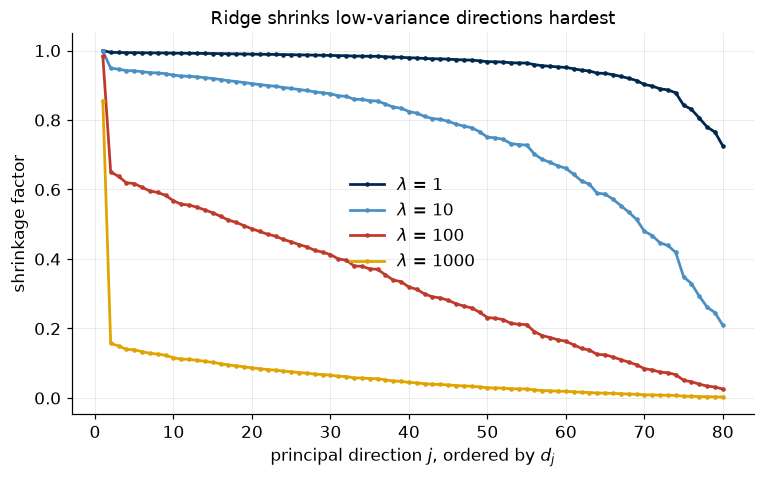

In [5]:
X_sim, y_sim, beta_sim = e5.simulate_sparse_regression(n=120, p=80, n_active=8, rho=0.5, seed=3)
d = np.linalg.svd(X_sim, compute_uv=False)

fig, ax = plt.subplots()
for lam in [1.0, 10.0, 100.0, 1000.0]:
    ax.plot(np.arange(1, len(d) + 1), d ** 2 / (d ** 2 + lam), marker=".", ms=4,
            label=f"$\\lambda$ = {lam:g}")
ax.set_xlabel("principal direction $j$, ordered by $d_j$")
ax.set_ylabel("shrinkage factor")
ax.set_title("Ridge shrinks low-variance directions hardest")
ax.legend()
plt.show()

The coefficient path shows the same thing in the original coordinates. Every coefficient moves smoothly towards zero, and none reaches it at any finite penalty.

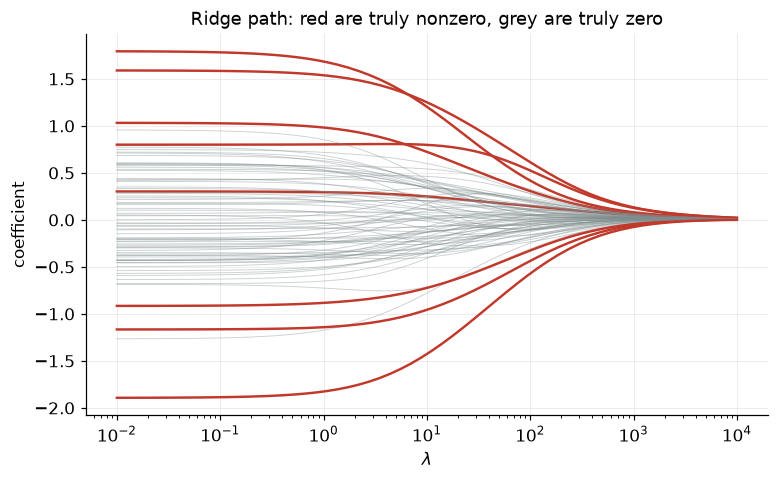

In [6]:
lam_path = np.logspace(-2, 4, 60)
ridge_path = np.array([ridge_fit(X_sim, y_sim, lam) for lam in lam_path])
active = np.flatnonzero(beta_sim)

fig, ax = plt.subplots()
for j in range(X_sim.shape[1]):
    is_active = j in active
    ax.plot(lam_path, ridge_path[:, j],
            color=e5.COLORS[2] if is_active else e5.COLORS[6],
            lw=1.6 if is_active else 0.6,
            alpha=1.0 if is_active else 0.4)
ax.set_xscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("coefficient")
ax.set_title("Ridge path: red are truly nonzero, grey are truly zero")
plt.show()

## Part 4. The LASSO

Replacing the squared penalty with an absolute one,

$$ \widehat{\boldsymbol{\beta}}^{\text{lasso}} = \arg\min_{\boldsymbol{\beta}} \; \frac{1}{2n}\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \lambda \|\boldsymbol{\beta}\|_1, $$

changes the geometry completely. The constraint region has corners on the axes, so the solution lands exactly on zero for many coefficients. There is no closed form, but there is a simple algorithm.

**Coordinate descent.** Cycle through coefficients one at a time. Holding the others fixed, the optimal value of $\beta_j$ is the least squares update passed through the soft-thresholding operator

$$ S(z, \gamma) = \operatorname{sign}(z)\,\max(|z| - \gamma, 0). $$

In [7]:
def soft_threshold(z, gamma):
    """Soft-thresholding operator."""
    return np.sign(z) * np.maximum(np.abs(z) - gamma, 0.0)


def lasso_coordinate_descent(X, y, lam, n_iter=200, tol=1e-8):
    """LASSO by cyclic coordinate descent on standardised predictors."""
    n, p = X.shape
    beta = np.zeros(p)
    resid = y.copy()
    col_norm = (X ** 2).sum(axis=0) / n

    for _ in range(n_iter):
        beta_old = beta.copy()
        for j in range(p):
            resid = resid + X[:, j] * beta[j]
            rho = X[:, j] @ resid / n
            beta[j] = soft_threshold(rho, lam) / col_norm[j]
            resid = resid - X[:, j] * beta[j]
        if np.max(np.abs(beta - beta_old)) < tol:
            break
    return beta


X_std = (X_sim - X_sim.mean(axis=0)) / X_sim.std(axis=0)
y_cen = y_sim - y_sim.mean()

beta_lasso = lasso_coordinate_descent(X_std, y_cen, lam=0.3)
print(f"nonzero coefficients: {np.sum(beta_lasso != 0)} out of {len(beta_lasso)}")
print(f"truly nonzero       : {len(active)}")
print(f"correctly selected  : {np.sum(beta_lasso[active] != 0)}")

nonzero coefficients: 12 out of 80
truly nonzero       : 8
correctly selected  : 8


Check the implementation against the reference one. Note the parametrisation: `scikit-learn` uses the same objective divided by $2n$, so the penalties are directly comparable.

In [8]:
from sklearn.linear_model import Lasso

sk_lasso = Lasso(alpha=0.3, fit_intercept=False, max_iter=100000).fit(X_std, y_cen)
print(f"maximum absolute difference from scikit-learn: "
      f"{np.max(np.abs(beta_lasso - sk_lasso.coef_)):.2e}")

maximum absolute difference from scikit-learn: 2.99e-04


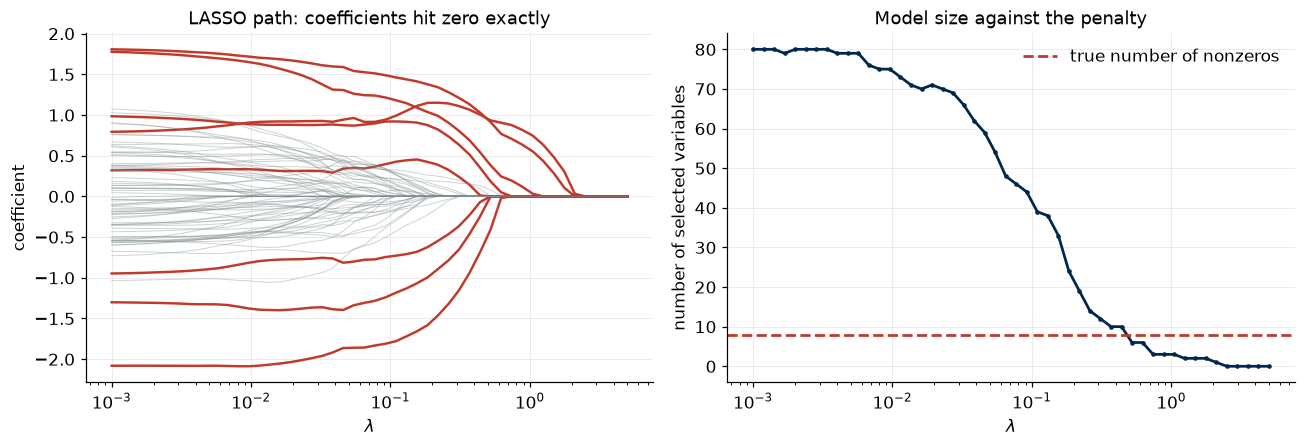

In [9]:
lasso_grid = np.logspace(-3, 0.7, 50)
lasso_path = np.array([lasso_coordinate_descent(X_std, y_cen, lam) for lam in lasso_grid])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for j in range(X_std.shape[1]):
    is_active = j in active
    axes[0].plot(lasso_grid, lasso_path[:, j],
                 color=e5.COLORS[2] if is_active else e5.COLORS[6],
                 lw=1.6 if is_active else 0.6, alpha=1.0 if is_active else 0.4)
axes[0].set_xscale("log")
axes[0].set_xlabel(r"$\lambda$")
axes[0].set_ylabel("coefficient")
axes[0].set_title("LASSO path: coefficients hit zero exactly")

axes[1].plot(lasso_grid, np.sum(lasso_path != 0, axis=1), marker=".", ms=4)
axes[1].axhline(len(active), color=e5.COLORS[2], ls="--", label="true number of nonzeros")
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$\lambda$")
axes[1].set_ylabel("number of selected variables")
axes[1].set_title("Model size against the penalty")
axes[1].legend()
fig.tight_layout()
plt.show()

### Exercise 2

Selection consistency is not the same as prediction accuracy, and the LASSO is much better at the second than the first.

1. Across the penalty grid, compute the number of true predictors selected (true positives) and the number of irrelevant predictors selected (false positives).
2. Plot both against $\lambda$.
3. Identify the penalty that minimises out-of-sample prediction error on a freshly simulated test set, and report how many false positives it admits.

Is the best predictive model the same as the correct model?

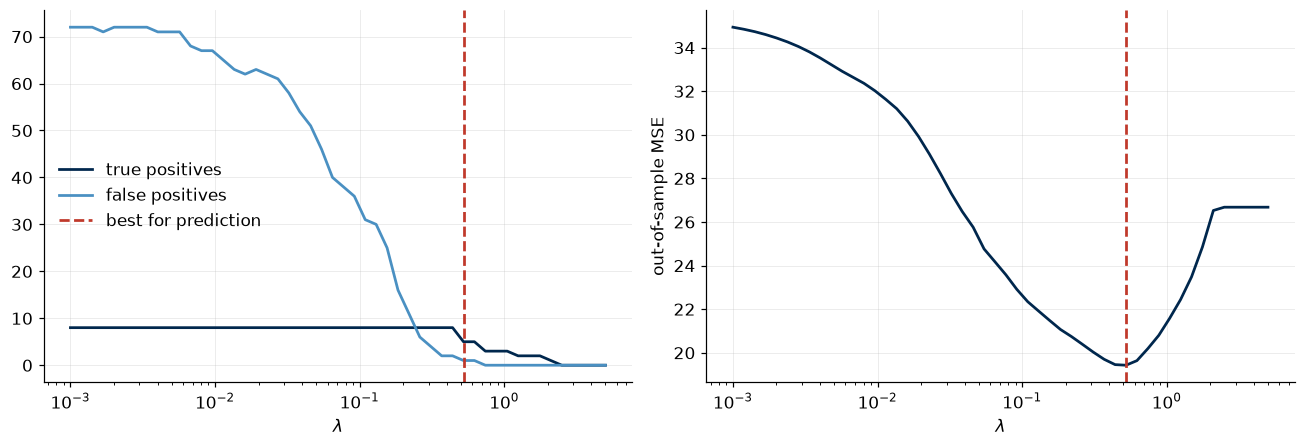

at the predictive optimum: 5 of 8 true predictors, 1 false positives


In [10]:
X_new, y_new, _ = e5.simulate_sparse_regression(n=500, p=80, n_active=8, rho=0.5, seed=3)
X_new_std = (X_new - X_sim.mean(axis=0)) / X_sim.std(axis=0)
y_new_cen = y_new - y_sim.mean()

truth = np.zeros(X_sim.shape[1], dtype=bool)
truth[active] = True

tp = [np.sum((path != 0) & truth) for path in lasso_path]
fp = [np.sum((path != 0) & ~truth) for path in lasso_path]
oos = [e5.mse(y_new_cen, X_new_std @ path) for path in lasso_path]

best = int(np.argmin(oos))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(lasso_grid, tp, label="true positives")
axes[0].plot(lasso_grid, fp, label="false positives")
axes[0].axvline(lasso_grid[best], color=e5.COLORS[2], ls="--", label="best for prediction")
axes[0].set_xscale("log")
axes[0].set_xlabel(r"$\lambda$")
axes[0].legend()

axes[1].plot(lasso_grid, oos)
axes[1].axvline(lasso_grid[best], color=e5.COLORS[2], ls="--")
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$\lambda$")
axes[1].set_ylabel("out-of-sample MSE")
fig.tight_layout()
plt.show()

print(f"at the predictive optimum: {tp[best]} of {len(active)} true predictors, "
      f"{fp[best]} false positives")

## Part 5. The elastic net

When predictors are strongly correlated the LASSO picks one of a correlated group essentially at random and discards the rest. That is unstable and, in macroeconomics where whole blocks of series move together, unhelpful. The elastic net combines both penalties,

$$ \lambda \left[ \alpha \|\boldsymbol{\beta}\|_1 + \frac{1-\alpha}{2} \|\boldsymbol{\beta}\|_2^2 \right], $$

and shares weight across correlated predictors rather than choosing arbitrarily.

In [11]:
from sklearn.linear_model import ElasticNet, Ridge

X_corr = X_std.copy()
X_corr[:, 1] = X_corr[:, 0] + 0.05 * rng.normal(size=len(X_corr))
X_corr[:, 2] = X_corr[:, 0] + 0.05 * rng.normal(size=len(X_corr))

comparison = pd.DataFrame({
    "LASSO": Lasso(alpha=0.2, fit_intercept=False, max_iter=100000).fit(X_corr, y_cen).coef_[:3],
    "elastic net": ElasticNet(alpha=0.2, l1_ratio=0.5, fit_intercept=False,
                              max_iter=100000).fit(X_corr, y_cen).coef_[:3],
    "ridge": Ridge(alpha=0.2 * len(y_cen), fit_intercept=False).fit(X_corr, y_cen).coef_[:3],
}, index=["x1", "x2 (copy of x1)", "x3 (copy of x1)"])

print(comparison.round(4))

                 LASSO  elastic net   ridge
x1                 0.0         -0.0  0.0405
x2 (copy of x1)   -0.0         -0.0  0.0106
x3 (copy of x1)    0.0         -0.0  0.0423


## Part 6. Choosing the penalty on real data

We now forecast the monthly change in the US unemployment rate, one month ahead, from three lags of every fully observed FRED-MD series: 363 predictors and roughly 700 monthly observations.

In [12]:
data, codes = e5.load_fredmd()
dataset = e5.build_forecast_dataset(data, codes, target="UNRATE", horizon=1, n_lags=3)

X, y, dates = dataset["X"], dataset["y"], dataset["dates"]
print(f"T = {len(y)} months from {dates[0]:%Y-%m} to {dates[-1]:%Y-%m}, p = {X.shape[1]} predictors")

split = int(0.7 * len(y))
X_tr, X_te, y_tr, y_te = X[:split], X[split:], y[:split], y[split:]
print(f"training to {dates[split - 1]:%Y-%m}, evaluation from {dates[split]:%Y-%m}")

T = 717 months from 1960-04 to 2019-12, p = 363 predictors
training to 2001-12, evaluation from 2002-01


Two rules that matter more than the choice of estimator.

**Standardise using training moments only.** The scaling of the test data must not be informed by the test data.

**Do not shuffle.** Ordinary $k$-fold cross-validation assigns future observations to the training folds. For time series, use forward-chaining splits, in which every validation fold lies strictly after its training data.

In [13]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV

Z_tr, Z_te, mu, sd = e5.standardise(X_tr, X_te)
y_mean = y_tr.mean()

tscv = TimeSeriesSplit(n_splits=5)

alpha_grid = np.logspace(-4, 1, 60)

fitted = {
    "ridge": RidgeCV(alphas=np.logspace(0, 7, 50), cv=tscv).fit(Z_tr, y_tr - y_mean),
    "LASSO": LassoCV(alphas=alpha_grid, cv=tscv, max_iter=50000).fit(Z_tr, y_tr - y_mean),
    "elastic net": ElasticNetCV(l1_ratio=[0.2, 0.5, 0.8], alphas=alpha_grid, cv=tscv,
                                max_iter=50000).fit(Z_tr, y_tr - y_mean),
}

C:\Users\dikor\anaconda3\envs\econ5129\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.194850e-03, tolerance: 1.476e-03
  model = cd_fast.enet_coordinate_descent_gram(


The benchmark is an autoregression on three lags of the target alone. Beating a small autoregressive model out of sample is a genuine achievement in macroeconomic forecasting, and most published methods do not.

In [14]:
ar_cols = [i for i, name in enumerate(dataset["names"]) if name.startswith("UNRATE.")]
b_ar, *_ = np.linalg.lstsq(np.column_stack([np.ones(split), X_tr[:, ar_cols]]), y_tr, rcond=None)
pred_ar = np.column_stack([np.ones(len(y_te)), X_te[:, ar_cols]]) @ b_ar

rows = [{"model": "AR(3) benchmark", "RMSE": e5.rmse(y_te, pred_ar),
         "out-of-sample $R^2$": 0.0, "nonzero coefficients": len(ar_cols)}]

for name, model in fitted.items():
    pred = model.predict(Z_te) + y_mean
    rows.append({
        "model": name,
        "RMSE": e5.rmse(y_te, pred),
        "out-of-sample $R^2$": e5.oos_r2(y_te, pred, benchmark=pred_ar),
        "nonzero coefficients": int(np.sum(model.coef_ != 0)),
    })

print(pd.DataFrame(rows).set_index("model").round(4))

                   RMSE  out-of-sample $R^2$  nonzero coefficients
model                                                             
AR(3) benchmark  0.1493               0.0000                     3
ridge            0.1337               0.1983                   363
LASSO            0.1347               0.1856                    28
elastic net      0.1342               0.1924                    34


The out-of-sample $R^2$ column is measured against the autoregressive benchmark, so a positive number means the penalised model genuinely adds something, and a negative one means the extra 360 predictors made matters worse.

Two lessons sit in that table. All three penalised estimators improve on the benchmark, and they do so by similar margins despite disagreeing sharply about how many predictors matter: ridge uses all 363, the LASSO a few dozen. When the predictors are this highly correlated, very different coefficient vectors can produce nearly identical forecasts, so a small difference in out-of-sample accuracy is not evidence about which description of the world is right. Lecture 4 returns to that question.

The second lesson is the size of the improvement. Reducing mean squared error by a fifth relative to a three-lag autoregression is a genuine result, and it is also about as much as the large macroeconomic literature on this problem typically delivers.

### Exercise 3

Forecast difficulty depends on the horizon.

1. Rebuild the dataset for horizons $h = 1, 3, 6$ and $12$ months using `e5.build_forecast_dataset`.
2. For each horizon, fit the LASSO and ridge with time series cross-validation and compute the out-of-sample $R^2$ against the autoregressive benchmark.
3. Plot the results against the horizon.

Does the advantage of the large information set grow or shrink as the horizon lengthens?

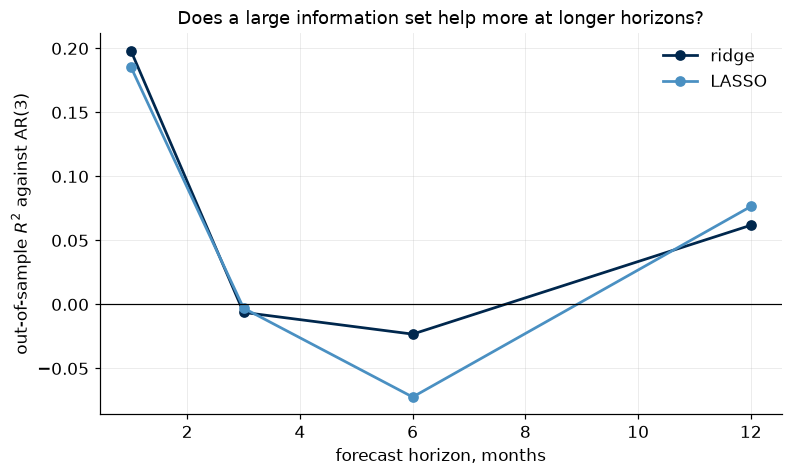

         ridge   LASSO
h = 1   0.1983  0.1856
h = 3  -0.0063 -0.0029
h = 6  -0.0232 -0.0724
h = 12  0.0618  0.0765


In [15]:
horizons = [1, 3, 6, 12]
scores = {"ridge": [], "LASSO": []}

for h in horizons:
    ds = e5.build_forecast_dataset(data, codes, target="UNRATE", horizon=h, n_lags=3)
    Xh, yh = ds["X"], ds["y"]
    s = int(0.7 * len(yh))
    Zh_tr, Zh_te, _, _ = e5.standardise(Xh[:s], Xh[s:])
    yh_tr, yh_te = yh[:s], yh[s:]

    ar_idx = [i for i, nm in enumerate(ds["names"]) if nm.startswith("UNRATE.")]
    b, *_ = np.linalg.lstsq(np.column_stack([np.ones(s), Xh[:s, ar_idx]]), yh_tr, rcond=None)
    bench = np.column_stack([np.ones(len(yh_te)), Xh[s:, ar_idx]]) @ b

    for name, model in [("ridge", RidgeCV(alphas=np.logspace(0, 7, 50), cv=TimeSeriesSplit(5))),
                        ("LASSO", LassoCV(alphas=alpha_grid, cv=TimeSeriesSplit(5), max_iter=50000))]:
        model.fit(Zh_tr, yh_tr - yh_tr.mean())
        pred = model.predict(Zh_te) + yh_tr.mean()
        scores[name].append(e5.oos_r2(yh_te, pred, benchmark=bench))

fig, ax = plt.subplots()
for name, vals in scores.items():
    ax.plot(horizons, vals, marker="o", label=name)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("forecast horizon, months")
ax.set_ylabel("out-of-sample $R^2$ against AR(3)")
ax.set_title("Does a large information set help more at longer horizons?")
ax.legend()
plt.show()

print(pd.DataFrame(scores, index=[f"h = {h}" for h in horizons]).round(4))

### Exercise 4

The LASSO selects a handful of series out of 363. Find out which.

1. Extract the nonzero coefficients from the LASSO fitted at $h = 1$ and sort them by absolute size.
2. Report the ten largest, with their variable names and lags.
3. Are they series a macroeconomist would have chosen by hand?

In [16]:
coef = fitted["LASSO"].coef_
selected = np.flatnonzero(coef)

order = selected[np.argsort(-np.abs(coef[selected]))][:10]
print(pd.DataFrame({
    "predictor": [dataset["names"][i] for i in order],
    "coefficient": coef[order],
}).round(4).to_string(index=False))

print(f"\ntotal selected: {len(selected)} of {X.shape[1]}")

  predictor  coefficient
 UEMPLT5.L1      -0.0266
   USTPU.L1      -0.0221
   IPMAT.L1      -0.0212
     HWI.L2      -0.0168
     BAA.L3       0.0117
NDMANEMP.L2      -0.0102
 T10YFFM.L1      -0.0102
     HWI.L1      -0.0095
FEDFUNDS.L3      -0.0095
 CLAIMSx.L1       0.0079

total selected: 28 of 363


## Take-home challenges

1. **The one standard error rule.** Cross-validation curves are flat near the optimum, so the usual advice is to choose the largest penalty within one standard error of the minimum. Implement it for the LASSO at $h = 1$, report how much smaller the selected model becomes, and whether out-of-sample accuracy suffers.

2. **Ridge as data augmentation.** Verify numerically that ridge with penalty $\lambda$ equals least squares applied to $\tilde{\mathbf{X}} = [\mathbf{X}; \sqrt{\lambda}\mathbf{I}]$ and $\tilde{\mathbf{y}} = [\mathbf{y}; \mathbf{0}]$, and connect the augmented rows to the Bayesian prior of Lab 1.

3. **Rolling versus expanding windows.** Replace the single split with an expanding window that refits every twelve months, using `e5.expanding_window_splits`. Does the ranking of the methods survive?

4. **Adaptive LASSO.** Weight the penalty on each coefficient by the inverse of a first-stage ridge estimate, refit, and compare selection accuracy on the simulated design of Part 4.

---

**Next**: Lecture 4 asks whether macroeconomic data is better described as a few strong common factors than as a handful of individually important series. Lab 4 builds principal components, compares them with ridge, and tests sparse against dense predictions.